# Titanic Survival Prediction

This project aims to predict whether a passenger survived the Titanic disaster using Machine Learning.

In [3]:
import pandas as pd
df = pd.read_csv("data/data/train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# Dataset Overview

In this section, we will understand the structure, columns, and basic information of the dataset.

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


# Checking Missing Values

Let's identify the columns that contain missing values before performing data preprocessing.

In [5]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

# Statistical Summary

The following summary provides basic statistical information about the numerical features.

In [6]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# Checking Duplicate Records

Let's check whether the dataset contains any duplicate rows.

In [7]:
df.duplicated().sum()

np.int64(0)

# Survival Distribution

This visualization shows the number of passengers who survived and those who did not survive.

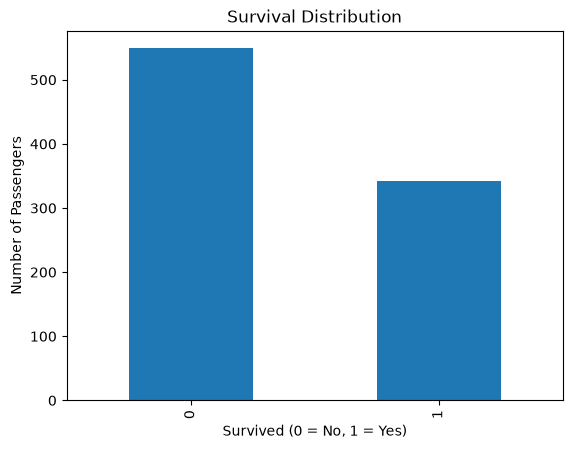

In [8]:
import matplotlib.pyplot as plt
df["Survived"].value_counts().plot(kind="bar")
plt.title("Survival Distribution")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")
plt.show()

# Survival by Gender

This analysis compares survival rates between male and female passengers.

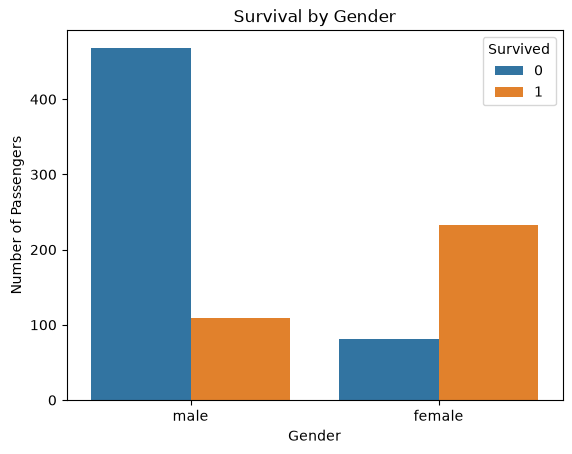

In [9]:
import seaborn as sns
sns.countplot(data=df, x="Sex", hue="Survived")
plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")
plt.show()

# Survival by Passenger Class

This analysis examines the relationship between passenger class and survival.

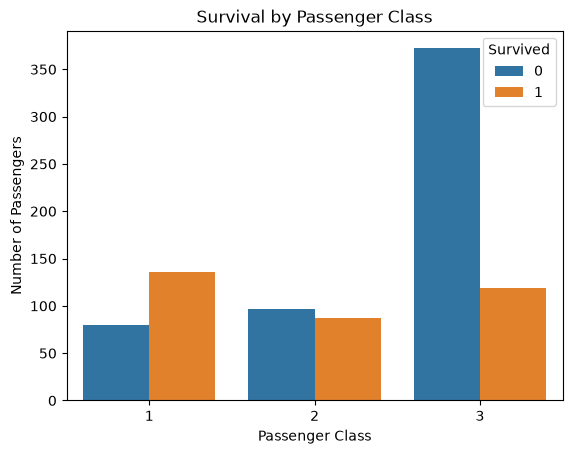

In [10]:
sns.countplot(data=df, x="Pclass", hue="Survived")
plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")
plt.show()

# Data Cleaning and Preprocessing

In this section, we will handle missing values and prepare the dataset for Machine Learning.

In [11]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

# Handling Missing Values

The Age column contains missing values, so we will fill them using the median age. 
The Embarked column contains a small number of missing values, so we will fill them using the most frequent value.

In [12]:
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Dropping Unnecessary Columns

Some columns such as PassengerId, Name, Ticket, and Cabin are not required for our initial prediction model, so we will remove them.

In [13]:
df = df.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])

# Encoding Categorical Features

Machine Learning models work with numerical values, so categorical features such as Sex and Embarked need to be converted into numerical form.

In [14]:
df = pd.get_dummies(df, columns=["Sex", "Embarked"], drop_first=True)

# Checking the Cleaned Dataset

Let's verify the dataset after cleaning and preprocessing.

In [15]:
df.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


In [16]:
df.isnull().sum()

Survived      0
Pclass        0
Age           0
SibSp         0
Parch         0
Fare          0
Sex_male      0
Embarked_Q    0
Embarked_S    0
dtype: int64

# Feature Selection

We will separate the target variable, Survived, from the input features used for prediction.

In [17]:
X = df.drop("Survived", axis=1)
y = df["Survived"]
print("Features:")
print(X.columns)
print("\nTarget:")
print(y.name)

Features:
Index(['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male', 'Embarked_Q',
       'Embarked_S'],
      dtype='str')

Target:
Survived


# Splitting the Dataset

The dataset will be divided into training and testing sets. The training data will be used to train the Machine Learning model, while the testing data will be used to evaluate its performance.

In [18]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y)
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (712, 8)
Testing data: (179, 8)


#  Feature Scaling

Feature scaling helps bring numerical features to a similar scale and can improve the performance of certain Machine Learning algorithms.

In [19]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model Training

We will train a Logistic Regression model to predict whether a passenger survived the Titanic disaster.

In [20]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)
print("Model training completed successfully.")

Model training completed successfully.


# Making Predictions

The trained model will now be used to predict survival outcomes for the test dataset.

In [21]:
y_pred = model.predict(X_test_scaled)
print("Predictions generated successfully.")
print(y_pred[:10])

Predictions generated successfully.
[0 0 0 0 1 0 1 0 0 0]


#  Model Evaluation

In this section, we will evaluate the performance of the Logistic Regression model using accuracy, classification report, and confusion matrix.

In [22]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

Model Accuracy: 0.8044692737430168
Accuracy Percentage: 80.44692737430168 %


# Classification Report

The classification report provides precision, recall, F1-score, and support for each class.

In [23]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.89      0.85       110
           1       0.79      0.67      0.72        69

    accuracy                           0.80       179
   macro avg       0.80      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179



# Confusion Matrix

The confusion matrix shows the number of correct and incorrect predictions made by the model for each class.

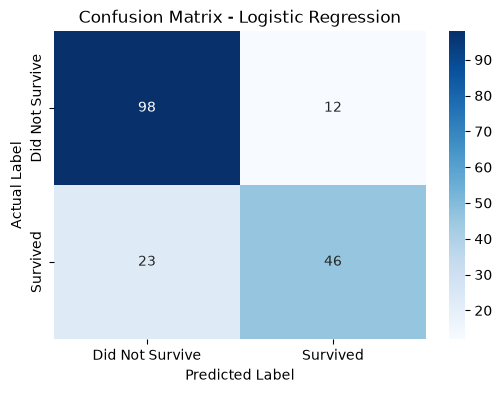

In [24]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Did Not Survive", "Survived"],
    yticklabels=["Did Not Survive", "Survived"])
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

# Model Performance Summary

The Logistic Regression model was evaluated using accuracy, precision, recall, F1-score, and a confusion matrix to understand its predictive performance.

In [25]:
print(f"Logistic Regression Accuracy: {accuracy * 100:.2f}%")

Logistic Regression Accuracy: 80.45%


# Random Forest Model

Random Forest is an ensemble Machine Learning algorithm that combines multiple decision trees to improve prediction performance and handle complex relationships in the data.

In [26]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
print("Random Forest model training completed successfully.")

Random Forest model training completed successfully.


# Random Forest Evaluation

We will evaluate the Random Forest model using accuracy and a classification report.

In [27]:
from sklearn.metrics import accuracy_score, classification_report
rf_accuracy = accuracy_score(y_test, rf_pred)
print(f"Random Forest Accuracy: {rf_accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))

Random Forest Accuracy: 81.56%

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.87      0.85       110
           1       0.78      0.72      0.75        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.82      0.81       179



# Random Forest Confusion Matrix

The confusion matrix helps visualize the correct and incorrect predictions made by the Random Forest model.

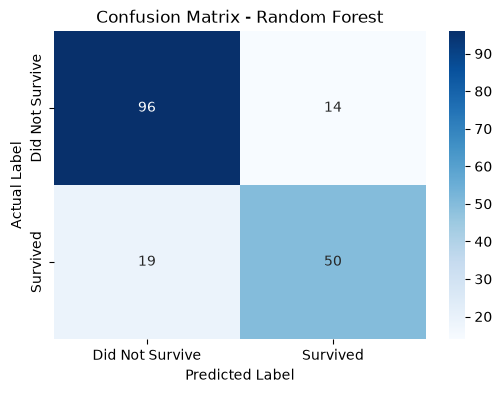

In [28]:
cm_rf = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Did Not Survive", "Survived"],
    yticklabels=["Did Not Survive", "Survived"])
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

#  Model Comparison

Let's compare the performance of Logistic Regression and Random Forest to identify the better-performing model.

In [29]:
print(f"Logistic Regression: {accuracy * 100:.2f}%")
print(f"Random Forest: {rf_accuracy * 100:.2f}%")

Logistic Regression: 80.45%
Random Forest: 81.56%


# Best Model Selection

Based on the evaluation results, Random Forest achieved higher accuracy than Logistic Regression. Therefore, Random Forest will be selected as the final model for deployment.

In [30]:
best_model = rf_model
print(f"Selected Model: Random Forest")
print(f"Accuracy: {rf_accuracy * 100:.2f}%")

Selected Model: Random Forest
Accuracy: 81.56%


# Saving the Final Model

The selected Random Forest model is saved using Joblib so that it can be loaded later in the prediction application.

In [31]:
import joblib
joblib.dump(best_model, "model.pkl")
print("Random Forest model saved successfully as model.pkl")

Random Forest model saved successfully as model.pkl
